In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# -------------------------------
# Generate TestRun Table
# -------------------------------
n_runs = 5000
serial_numbers = np.random.randint(1000, 4020, n_runs)

test_runs = pd.DataFrame({
    "TestRun_Key": range(1, n_runs+1),
    "SerialNumber": serial_numbers,
    "MaterialNumber": np.random.choice(["0629", "0145", "0850", "0906"], n_runs),
    "MaterialText": np.random.choice([
        "WBoardX",
        "M3NN0X",
        "ME10TX",
        "LE100TX"], n_runs),
    "MaterialRevision": np.random.choice(["A001","B001","C201"], n_runs),
    "Lot": np.random.randint(250000, 330000, n_runs),
    "Station": np.random.choice(["Station00","StationAB"], n_runs),
    "Routestep": np.random.choice(["2AB","3AB"], n_runs),
    "OperatorName": np.random.choice(["Wella","Shruti","rizwan","Max","joseph"], n_runs),
    "SoftwareVersion": np.random.choice(["11.1.9.50","11.2.9.51","11.4.9.52"], n_runs),
    "ComputerName": np.random.choice(["SS1M","SS2M","SS3M"], n_runs),
    "OperatingSystem": np.random.choice(["Win10","Win11","Linux"], n_runs),
    "SequencerId": np.random.choice(["1","2","3"], n_runs),
    "Duration_s": np.random.normal(500, 60, n_runs),
    "StartTime": pd.date_range("2024-01-01", periods=n_runs, freq="min")
})

# -------------------------------
# Generate TestItem Table
# -------------------------------
n_items = n_runs * 5  # 5 items per run
test_items = pd.DataFrame({
    "TestItem_Key": range(1, n_items+1),
    "TestRun_Key": np.repeat(test_runs["TestRun_Key"].values, 5),
    "Idx": np.tile(range(1,6), n_runs),
    "Name": np.tile(["Power_check","AI_check","Humility_check","Memory_Test","USB_board_defect"], n_runs),
})

# Assign results (with some randomness)
test_items["Result"] = np.where(np.random.rand(n_items) < 0.9, "PASSED", "FAILED")
test_items["Stdout"] = np.random.choice(["OK","Not Executed well","All good","Threshold within limits"], n_items)
test_items["Stderr"] = np.where(
    test_items["Result"]=="FAILED",
    np.random.choice(["Error:spike","Warning: Temp High","Error: Voltage Drop"], n_items),
    ""
)
test_items["Comment"] = np.random.choice(["Auto OK","Manual check","Operator note","Retest recommended"], n_items)
test_items["Duration_s"] = np.random.normal(10, 2, n_items)
test_items["StartTime"] = pd.date_range("2024-01-01", periods=n_items, freq="s")

# -------------------------------
# Link Item Results to Run Results
# -------------------------------
# Mark a run as FAILED if any of its items failed
run_failures = test_items.groupby("TestRun_Key")["Result"].apply(lambda x: (x=="FAILED").any()).reset_index()
run_failures.rename(columns={"Result":"AnyItemFailed"}, inplace=True)

test_runs = test_runs.merge(run_failures, on="TestRun_Key", how="left")
test_runs["Result"] = np.where(test_runs["AnyItemFailed"], "FAILED", "PASSED")

# Compute FPY and Retest Count
first_attempts = test_runs.sort_values("StartTime").groupby("SerialNumber").first().reset_index()
first_attempts = first_attempts[["SerialNumber","Result"]].rename(columns={"Result":"FirstResult"})
test_runs = test_runs.merge(first_attempts, on="SerialNumber", how="left")
test_runs["FirstPassYield"] = (test_runs["FirstResult"]=="PASSED").astype(int)
retest_counts = test_runs.groupby("SerialNumber").size().reset_index(name="RetestCount")
test_runs = test_runs.merge(retest_counts, on="SerialNumber", how="left")

# Save
test_runs.to_csv("../data/demo_test_runs.csv", index=False)
test_items.to_csv("../data/demo_test_items.csv", index=False)

print("✅ Demo datasets created")
print("Runs shape:", test_runs.shape, " | Items shape:", test_items.shape)
print("Class distribution:\n", test_runs["Result"].value_counts(normalize=True))
print("FPY rate:", test_runs["FirstPassYield"].mean())


✅ Demo datasets created
Runs shape: (5000, 20)  | Items shape: (25000, 10)
Class distribution:
 Result
PASSED    0.5896
FAILED    0.4104
Name: proportion, dtype: float64
FPY rate: 0.5948


✅ Columns in merged: ['TestItem_Key', 'TestRun_Key', 'Idx', 'Name', 'Result_x', 'Stdout', 'Stderr', 'Comment', 'Duration_s', 'StartTime', 'Station', 'OperatorName', 'MaterialNumber', 'Result_y']
✅ Using result column: Result_x
✅ Final features used: ['TestItem_Key', 'TestRun_Key', 'Idx', 'Name', 'Stdout', 'Stderr', 'Comment', 'Duration_s', 'Station', 'OperatorName', 'MaterialNumber']

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6744
           1       1.00      1.00      1.00       756

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500


🔴 Top 10 Test Types Predicted to Fail:
               Name  PredictedProb
4  USB_board_defect       0.109928
0          AI_check       0.104987
3       Power_check       0.098142
2       Memory_Test       0.093632
1    Humility_check       0.091174

🟢 Top 10 

C:\Users\sharmas\AppData\Local\Temp\ipykernel_13244\628925974.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PredictedProb", y="Name", data=top_failed_pred, palette="Reds_r")


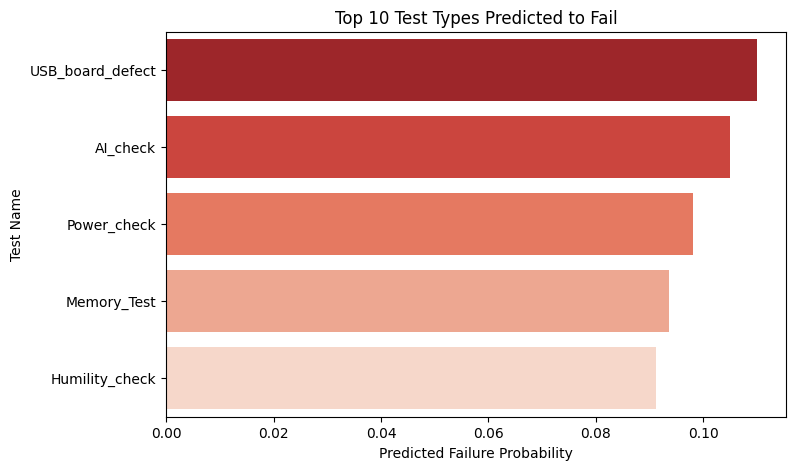

C:\Users\sharmas\AppData\Local\Temp\ipykernel_13244\628925974.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PredictedProb", y="Name", data=top_passed_pred, palette="Greens_r")


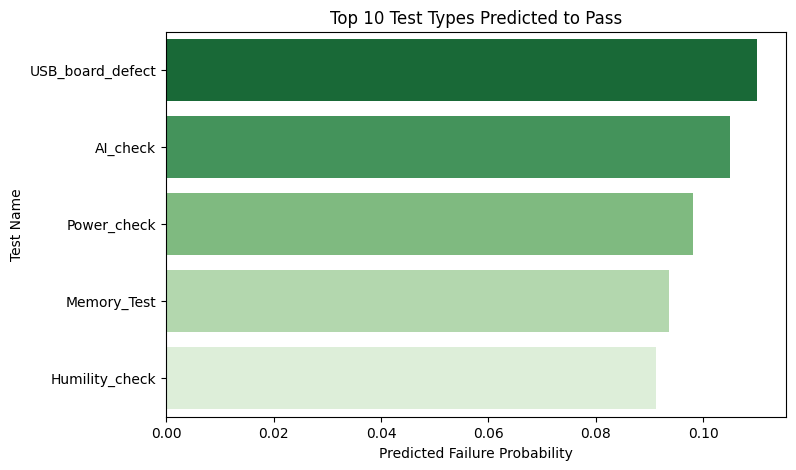

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
test_runs = pd.read_csv("../data/demo_test_runs.csv")
test_items = pd.read_csv("../data/demo_test_items.csv")

# Merge test_items with test_runs
merged = test_items.merge(
    test_runs[["TestRun_Key", "Station", "OperatorName", "MaterialNumber", "Result"]],
    on="TestRun_Key",
    how="left"
)

print("✅ Columns in merged:", merged.columns.tolist())

# Figure out which column has the actual results
result_col = None
for col in ["Result", "Result_x", "Result_y"]:
    if col in merged.columns:
        result_col = col
        break

if not result_col:
    raise ValueError("❌ No Result column found in merged data!")

print(f"✅ Using result column: {result_col}")

# Prepare DataFrame for ML
df = merged.copy()

# Encode categorical columns
label_cols = ["Name","Parameters","Stdout","Stderr","Comment","Station","OperatorName","MaterialNumber"]
for col in label_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# Drop unusable columns (non-numeric, object types)
df = df.drop(columns=df.select_dtypes(include=["object", "datetime"]).columns, errors="ignore")

# Features & Target
X = df.drop(columns=[result_col], errors="ignore")
y = (merged[result_col] == "FAILED").astype(int)

print("✅ Final features used:", X.columns.tolist())

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=200)
model.fit(X_train, y_train)

# Predictions
merged.loc[X_test.index, "PredictedProb"] = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# --- Rank tests by predicted failure probability ---
pred_fail_probs = merged.groupby("Name")["PredictedProb"].mean().reset_index()
pred_fail_probs = pred_fail_probs.sort_values("PredictedProb", ascending=False)

# Top 10 failure-prone
top_failed_pred = pred_fail_probs.head(20)
# Top 10 most reliable
top_passed_pred = pred_fail_probs.tail(20)

print("\n🔴 Top 10 Test Types Predicted to Fail:")
print(top_failed_pred)

print("\n🟢 Top 10 Test Types Predicted to Pass:")
print(top_passed_pred)

# --- Visualization ---
plt.figure(figsize=(8,5))
sns.barplot(x="PredictedProb", y="Name", data=top_failed_pred, palette="Reds_r")
plt.title("Top 10 Test Types Predicted to Fail")
plt.xlabel("Predicted Failure Probability")
plt.ylabel("Test Name")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="PredictedProb", y="Name", data=top_passed_pred, palette="Greens_r")
plt.title("Top 10 Test Types Predicted to Pass")
plt.xlabel("Predicted Failure Probability")
plt.ylabel("Test Name")
plt.show()